Building an End-to-End Data Engineering Pipeline for E-Commerce Order Analytics

Step 1: EXTRACT - Baca Data Mentah

In [183]:
from pathlib import Path
import pandas as pd
import numpy as np  
import ast
# Import semua data raw 
data = pd.read_csv("../data/raw/raw_orders.csv")

data.head(10)

,order_id,product_id,product_name,kategori,quantity,total_harga,tanggal_order,kota,channel,status,customer_email
0,ORD-10122,P009,Kahf EDT Revered Oud,Fragrance,3,447000.0,"Jul 06, 2024",Denpasar,Website,cancelled,customer3@email.com
1,ORD-10107,P008,Kahf Hair Tonic,Hair Care,3,126000.0,2024-07-12 09:31:00,solo,marketplace,pending,customer45@email.com
2,ORD-10128,P001,Kahf Oil & Acne Care Facial Wash,Face Care,1,32000.0,2024-05-19 16:47:00,Jakarta,website,pending,customer9@email.com
3,ORD-10001,P008,Kahf Hair Tonic,Hair Care,5,210000.0,2024-05-24 20:39:00,Bandung,marketplace,completed,customer13@email.com
4,ORD-10053,P002,Kahf Skin Energizing & Brightening Face Wash,Face Care,1,34000.0,"Jul 08, 2024",Malang,marketplace,cancelled,customer22@email.com
5,ORD-10022,P007,Kahf Deodorant Roll On,Body Care,5,125000.0,06/07/2024,makassar,MARKETPLACE,pending,customer6@email.com
6,ORD-10019,P006,Kahf Hair & Body Wash,Body Care,1,38000.0,"Jul 09, 2024",jakarta,MOBILE_APP,cancelled,NaN
7,ORD-10030,P008,Kahf Hair Tonic,Hair Care,1,42000.0,2024-05-10,MEDAN,mobile_app,cancelled,customer24@email.com
8,ORD-10038,P009,Kahf EDT Revered Oud,Fragrance,2,298000.0,15/05/2024,Yogyakarta,MARKETPLACE,shipped,customer35@email.com
9,ORD-10125,P007,Kahf Deodorant Roll On,Body Care,5,125000.0,10/05/2024,bandung,MOBILE_APP,cancelled,customer2@email.com


In [184]:
print("\nDuplikasi")
print(f"{data.duplicated().sum()}")


Duplikasi
0


In [185]:
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
order_id           0
product_id         0
product_name       0
kategori           0
quantity           0
total_harga        7
tanggal_order      0
kota               0
channel            0
status             0
customer_email    21
dtype: int64


In [186]:
data.nunique()

order_id          130
product_id         10
product_name       10
kategori            4
quantity            5
total_harga        43
tanggal_order     115
kota               24
channel             6
status              4
customer_email     41
dtype: int64

In [187]:
# Nilai Negatif
total_harga_negatif = data[data['total_harga'] < 0]
print(total_harga_negatif)

     order_id product_id                   product_name   kategori  quantity  \
19  ORD-10129       P009           Kahf EDT Revered Oud  Fragrance         1   
56  ORD-10016       P004  Kahf Acne Spot Solution Serum  Face Care         1   
63  ORD-10020       P006          Kahf Hair & Body Wash  Body Care         3   

    total_harga tanggal_order     kota      channel     status  \
19    -149000.0    24/06/2024  jakarta   MOBILE_APP  cancelled   
56     -58000.0    08/05/2024  BANDUNG   mobile_app  cancelled   
63    -114000.0    23/06/2024     solo  MARKETPLACE    pending   

          customer_email  
19  customer31@email.com  
56  customer16@email.com  
63   customer5@email.com  


Step 2: TRANSFORM - Bersihkan Data

In [188]:
# Standarisasi penulisan kalimat pada kolom menjadi lebih rapi
kolom = ['product_name','kategori','kota','channel','status']
# Standardisasi setiap kolom
for col in kolom:
    data[col] = (
        data[col]
        .astype(str)
        .str.strip()
        .str.replace('_', ' ', regex=False)   # Mengganti _ menjadi spasi
        .str.replace(r'\s+', ' ', regex=True) # Menghapus spasi ganda
        .str.title())                          # Huruf awal setiap kata kapital
# Tampilkan hasil
print(data[kolom].head())

                                   product_name   kategori      kota  \
0                          Kahf Edt Revered Oud  Fragrance  Denpasar   
1                               Kahf Hair Tonic  Hair Care      Solo   
2              Kahf Oil & Acne Care Facial Wash  Face Care   Jakarta   
3                               Kahf Hair Tonic  Hair Care   Bandung   
4  Kahf Skin Energizing & Brightening Face Wash  Face Care    Malang   

       channel     status  
0      Website  Cancelled  
1  Marketplace    Pending  
2      Website    Pending  
3  Marketplace  Completed  
4  Marketplace  Cancelled  


In [189]:
# Mengisi email kosong deengan dummy karena hanya emanya saja yang kosong maka
# akan lebih bagus jika kita masukkan email dummy saja
# Mengisi missing value pada kolom email
data['customer_email'] = data['customer_email'].fillna('dummy123@gmail.com')

# Menampilkan hasil
print(data[['customer_email']])

           customer_email
0     customer3@email.com
1    customer45@email.com
2     customer9@email.com
3    customer13@email.com
4    customer22@email.com
..                    ...
125  customer24@email.com
126  customer41@email.com
127  customer32@email.com
128  customer19@email.com
129    dummy123@gmail.com

[130 rows x 1 columns]


In [190]:
# Menampilkan hasil
print(data[['quantity', 'total_harga']])

     quantity  total_harga
0           3     447000.0
1           3     126000.0
2           1      32000.0
3           5     210000.0
4           1      34000.0
..        ...          ...
125         4     100000.0
126         1      38000.0
127         3     195000.0
128         1      65000.0
129         4     136000.0

[130 rows x 2 columns]


In [191]:
# Mengubah semua nilai total_harga negatif menjadi positif karena
# Hanya bernilai negatif saja bukan salah nilainya
data['total_harga'] = data['total_harga'].abs()
print("Jumlah total_harga negatif:",
      (data['total_harga'] < 0).sum())

Jumlah total_harga negatif: 0


In [192]:
# Menambhakan kolom harga karena ada total harga yang kosong dan quantoty nya ada
# Pengalian saja
display(data[data['total_harga'].isna()])

,order_id,product_id,product_name,kategori,quantity,total_harga,tanggal_order,kota,channel,status,customer_email
13,ORD-10048,P002,Kahf Skin Energizing & Brightening Face Wash,Face Care,1,NaN,2024-07-12 04:12:00,Bandung,Website,Cancelled,customer33@email.com
16,ORD-10097,P002,Kahf Skin Energizing & Brightening Face Wash,Face Care,2,NaN,22/06/2024,Semarang,Website,Cancelled,customer28@email.com
36,ORD-10126,P010,Kahf Edt Humbling Forest,Fragrance,1,NaN,"Jun 10, 2024",Yogyakarta,Marketplace,Cancelled,customer45@email.com
43,ORD-10043,P004,Kahf Acne Spot Solution Serum,Face Care,4,NaN,2024-07-18,Denpasar,Mobile App,Cancelled,customer34@email.com
57,ORD-10090,P010,Kahf Edt Humbling Forest,Fragrance,2,NaN,27/07/2024,Solo,Marketplace,Pending,customer13@email.com
74,ORD-10003,P009,Kahf Edt Revered Oud,Fragrance,1,NaN,16/07/2024,Solo,Marketplace,Cancelled,customer16@email.com
91,ORD-10113,P004,Kahf Acne Spot Solution Serum,Face Care,2,NaN,2024-06-27 04:22:00,Yogyakarta,Marketplace,Completed,customer29@email.com


In [193]:
data2 = pd.read_csv("../data/raw/raw_products.csv")
data2.head(10)

,product_id,product_name,kategori,harga_satuan
0,P001,Kahf Oil & Acne Care Facial Wash,Face Care,32000
1,P002,Kahf Skin Energizing & Brightening Face Wash,Face Care,34000
2,P003,Kahf Hydro Balance Moisturizer,Face Care,45000
3,P004,Kahf Acne Spot Solution Serum,Face Care,58000
4,P005,Kahf Aqua Matte Sunscreen SPF50,Face Care,65000
5,P006,Kahf Hair & Body Wash,Body Care,38000
6,P007,Kahf Deodorant Roll On,Body Care,25000
7,P008,Kahf Hair Tonic,Hair Care,42000
8,P009,Kahf EDT Revered Oud,Fragrance,149000
9,P010,Kahf EDT Humbling Forest,Fragrance,149000


In [194]:
print(data.columns.tolist())
print(data2.columns.tolist())

['order_id', 'product_id', 'product_name', 'kategori', 'quantity', 'total_harga', 'tanggal_order', 'kota', 'channel', 'status', 'customer_email']
['product_id', 'product_name', 'kategori', 'harga_satuan']


In [195]:
data['product_id'] = (
    data['product_id']
    .astype(str)
    .str.strip())
data2['product_id'] = (
    data2['product_id']
    .astype(str)
    .str.strip())

In [196]:
set(data['product_id']) - set(data2['product_id'])

set()

In [197]:
# Menambahakan harga_satuan dari dataset product
data = data.merge(
    data2[['product_id', 'harga_satuan']],
    on='product_id',
    how='left')
data.head()

,order_id,product_id,product_name,kategori,quantity,total_harga,tanggal_order,kota,channel,status,customer_email,harga_satuan
0,ORD-10122,P009,Kahf Edt Revered Oud,Fragrance,3,447000.0,"Jul 06, 2024",Denpasar,Website,Cancelled,customer3@email.com,149000
1,ORD-10107,P008,Kahf Hair Tonic,Hair Care,3,126000.0,2024-07-12 09:31:00,Solo,Marketplace,Pending,customer45@email.com,42000
2,ORD-10128,P001,Kahf Oil & Acne Care Facial Wash,Face Care,1,32000.0,2024-05-19 16:47:00,Jakarta,Website,Pending,customer9@email.com,32000
3,ORD-10001,P008,Kahf Hair Tonic,Hair Care,5,210000.0,2024-05-24 20:39:00,Bandung,Marketplace,Completed,customer13@email.com,42000
4,ORD-10053,P002,Kahf Skin Energizing & Brightening Face Wash,Face Care,1,34000.0,"Jul 08, 2024",Malang,Marketplace,Cancelled,customer22@email.com,34000


In [198]:
print(data['harga_satuan'].isna().sum())

0


In [199]:
# Mengisi total harga yang kosong 
data.loc[data['total_harga'].isna(),'total_harga'] = (data['quantity'] * data['harga_satuan'])

In [200]:
print(data['total_harga'].isna().sum())

0


In [201]:
# Mengubah total_harga menjadi nilai angka normal agar formatnya sama harga_satuan
(data[['total_harga']].isna().sum())
data['total_harga'] = data['total_harga'].astype(int)
data.head(10)

,order_id,product_id,product_name,kategori,quantity,total_harga,tanggal_order,kota,channel,status,customer_email,harga_satuan
0,ORD-10122,P009,Kahf Edt Revered Oud,Fragrance,3,447000,"Jul 06, 2024",Denpasar,Website,Cancelled,customer3@email.com,149000
1,ORD-10107,P008,Kahf Hair Tonic,Hair Care,3,126000,2024-07-12 09:31:00,Solo,Marketplace,Pending,customer45@email.com,42000
2,ORD-10128,P001,Kahf Oil & Acne Care Facial Wash,Face Care,1,32000,2024-05-19 16:47:00,Jakarta,Website,Pending,customer9@email.com,32000
3,ORD-10001,P008,Kahf Hair Tonic,Hair Care,5,210000,2024-05-24 20:39:00,Bandung,Marketplace,Completed,customer13@email.com,42000
4,ORD-10053,P002,Kahf Skin Energizing & Brightening Face Wash,Face Care,1,34000,"Jul 08, 2024",Malang,Marketplace,Cancelled,customer22@email.com,34000
5,ORD-10022,P007,Kahf Deodorant Roll On,Body Care,5,125000,06/07/2024,Makassar,Marketplace,Pending,customer6@email.com,25000
6,ORD-10019,P006,Kahf Hair & Body Wash,Body Care,1,38000,"Jul 09, 2024",Jakarta,Mobile App,Cancelled,dummy123@gmail.com,38000
7,ORD-10030,P008,Kahf Hair Tonic,Hair Care,1,42000,2024-05-10,Medan,Mobile App,Cancelled,customer24@email.com,42000
8,ORD-10038,P009,Kahf Edt Revered Oud,Fragrance,2,298000,15/05/2024,Yogyakarta,Marketplace,Shipped,customer35@email.com,149000
9,ORD-10125,P007,Kahf Deodorant Roll On,Body Care,5,125000,10/05/2024,Bandung,Mobile App,Cancelled,customer2@email.com,25000


In [202]:
# Mengubah format tanggal menjadi standar ISO 2024-06-27
# Mengubah berbagai format tanggal menjadi datetime
data['tanggal_order'] = pd.to_datetime(
    data['tanggal_order'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)
data['tanggal_order'] = data['tanggal_order'].dt.strftime('%Y-%m-%d')
print(data['tanggal_order'].isna().sum())
data.head()

0


,order_id,product_id,product_name,kategori,quantity,total_harga,tanggal_order,kota,channel,status,customer_email,harga_satuan
0,ORD-10122,P009,Kahf Edt Revered Oud,Fragrance,3,447000,2024-07-06,Denpasar,Website,Cancelled,customer3@email.com,149000
1,ORD-10107,P008,Kahf Hair Tonic,Hair Care,3,126000,2024-12-07,Solo,Marketplace,Pending,customer45@email.com,42000
2,ORD-10128,P001,Kahf Oil & Acne Care Facial Wash,Face Care,1,32000,2024-05-19,Jakarta,Website,Pending,customer9@email.com,32000
3,ORD-10001,P008,Kahf Hair Tonic,Hair Care,5,210000,2024-05-24,Bandung,Marketplace,Completed,customer13@email.com,42000
4,ORD-10053,P002,Kahf Skin Energizing & Brightening Face Wash,Face Care,1,34000,2024-07-08,Malang,Marketplace,Cancelled,customer22@email.com,34000


Visualisasi Hasil Analisis

In [203]:
total_revenue = data['total_harga'].sum()

print(f"Total Revenue : Rp {total_revenue:,.0f}")

Total Revenue : Rp 19,919,000


In [204]:
total_orders = data['order_id'].nunique()

print(total_orders)

130


In [205]:
total_qty = data['quantity'].sum()

print(total_qty)

312


In [206]:
aov = (
    data['total_harga'].sum()
    /
    data['order_id'].nunique()
)

print(f"Rp {aov:,.0f}")

Rp 153,223


In [207]:
cancel_rate = (
    (data['status'] == 'Cancelled').sum()
    /
    len(data)
) * 100

print(f"{cancel_rate:.2f}%")

30.77%


In [208]:
top_product = (
    data.groupby('product_name')['quantity']
    .sum()
    .sort_values(ascending=False)
)

print(top_product.head())

product_name
Kahf Deodorant Roll On                          47
Kahf Aqua Matte Sunscreen Spf50                 42
Kahf Skin Energizing & Brightening Face Wash    37
Kahf Edt Revered Oud                            35
Kahf Hydro Balance Moisturizer                  29
Name: quantity, dtype: int64


In [209]:
top_city = (
    data.groupby('kota')['total_harga']
    .sum()
    .sort_values(ascending=False)
)

print(top_city.head())

kota
Bandung     4010000
Malang      2652000
Makassar    2306000
Denpasar    1859000
Solo        1850000
Name: total_harga, dtype: int64


In [210]:
top_channel = (
    data.groupby('channel')['total_harga']
    .sum()
    .sort_values(ascending=False)
)

print(top_channel)

channel
Website        7227000
Marketplace    7115000
Mobile App     5577000
Name: total_harga, dtype: int64


In [211]:
print("="*60)

print("E-COMMERCE SALES DASHBOARD")

print("="*60)

print(f"Total Revenue        : Rp {total_revenue:,.0f}")
print(f"Total Orders         : {total_orders}")
print(f"Total Quantity Sold  : {total_qty}")
print(f"Average Order Value  : Rp {aov:,.0f}")
print(f"Cancellation Rate    : {cancel_rate:.2f}%")

print("="*60)

print(f"Top Product          : {top_product.index[0]}")
print(f"Top Revenue City     : {top_city.index[0]}")
print(f"Best Channel         : {top_channel.index[0]}")

print("="*60)

E-COMMERCE SALES DASHBOARD
Total Revenue        : Rp 19,919,000
Total Orders         : 130
Total Quantity Sold  : 312
Average Order Value  : Rp 153,223
Cancellation Rate    : 30.77%
Top Product          : Kahf Deodorant Roll On
Top Revenue City     : Bandung
Best Channel         : Website


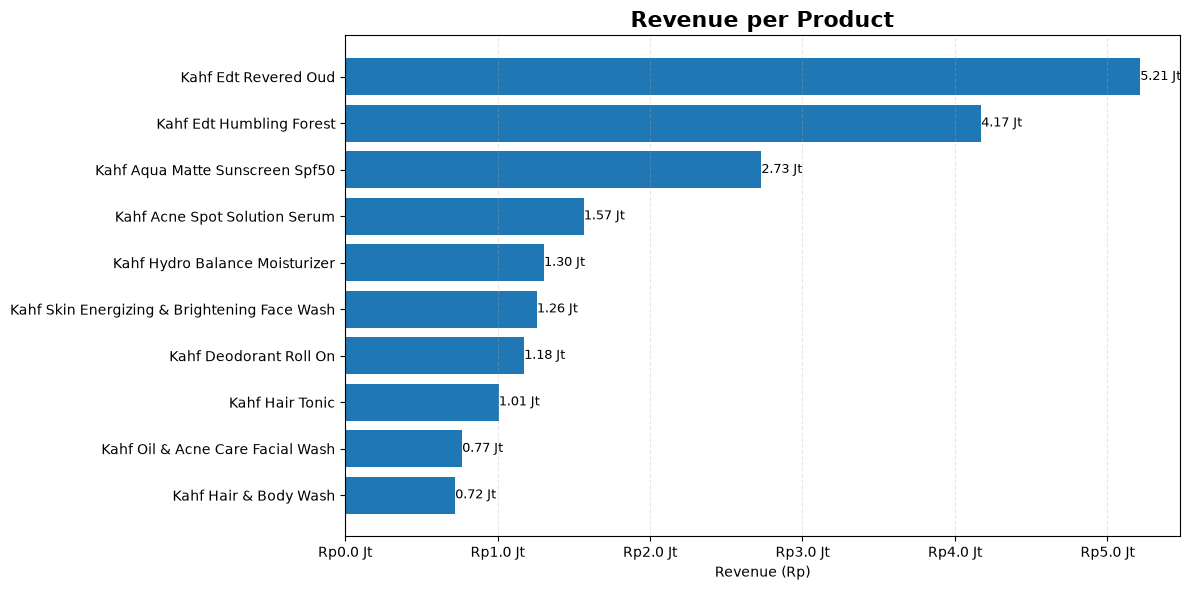

In [212]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

revenue_product = (
    data.groupby('product_name')['total_harga']
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,6))

bars = plt.barh(
    revenue_product.index,
    revenue_product.values
)

plt.title('Revenue per Product', fontsize=16, fontweight='bold')

plt.xlabel('Revenue (Rp)')
plt.ylabel('')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'Rp{x/1e6:.1f} Jt')
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f'{width/1e6:.2f} Jt',
        va='center',
        fontsize=9
    )

plt.tight_layout()

plt.show()

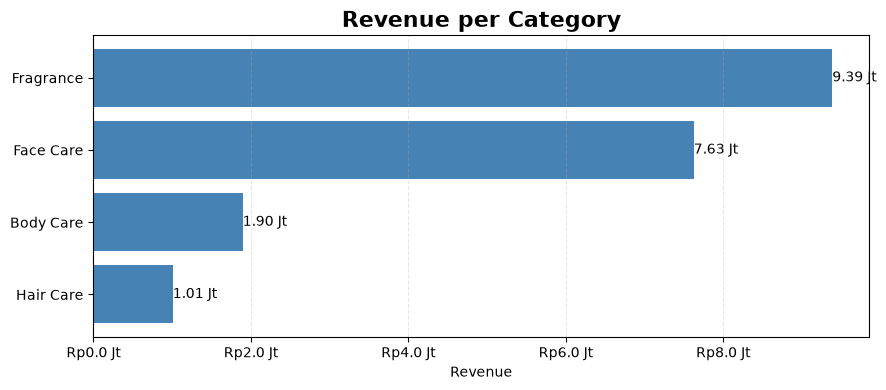

In [213]:
from matplotlib.ticker import FuncFormatter
revenue_category = (
    data.groupby('kategori')['total_harga']
    .sum()
    .sort_values()
)

plt.figure(figsize=(9,4))

bars = plt.barh(
    revenue_category.index,
    revenue_category.values,
    color='steelblue'
)

plt.title("Revenue per Category", fontsize=16, weight='bold')
plt.xlabel("Revenue")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"Rp{x/1e6:.1f} Jt")
)

for bar in bars:
    width = bar.get_width()
    plt.text(width,
             bar.get_y()+bar.get_height()/2,
             f"{width/1e6:.2f} Jt",
             va='center')

plt.tight_layout()
plt.show()

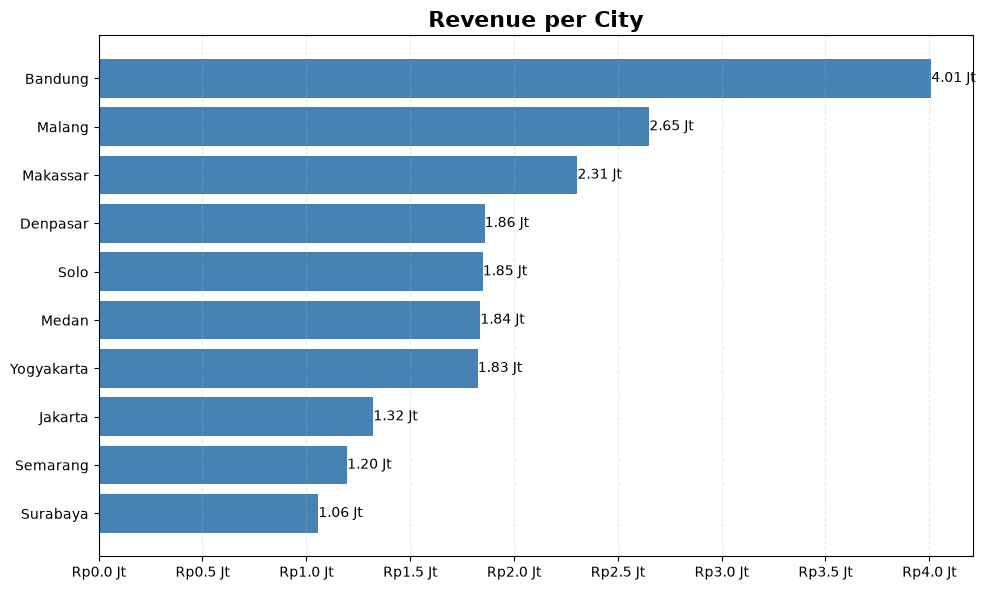

In [214]:
revenue_city = (
    data.groupby('kota')['total_harga']
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    revenue_city.index,
    revenue_city.values,
    color='steelblue'
)

plt.title("Revenue per City", fontsize=16, weight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"Rp{x/1e6:.1f} Jt")
)

for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y()+bar.get_height()/2,
             f"{bar.get_width()/1e6:.2f} Jt",
             va='center')

plt.tight_layout()
plt.show()

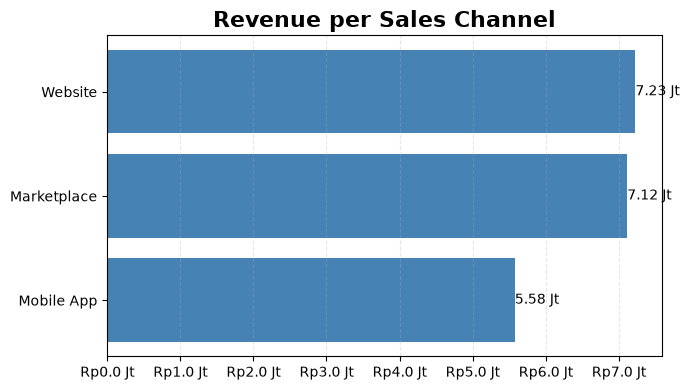

In [215]:
revenue_channel = (
    data.groupby('channel')['total_harga']
    .sum()
    .sort_values()
)

plt.figure(figsize=(7,4))

bars = plt.barh(
    revenue_channel.index,
    revenue_channel.values,
    color='steelblue'
)

plt.title("Revenue per Sales Channel", fontsize=16, weight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"Rp{x/1e6:.1f} Jt")
)

for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y()+bar.get_height()/2,
             f"{bar.get_width()/1e6:.2f} Jt",
             va='center')

plt.tight_layout()
plt.show()

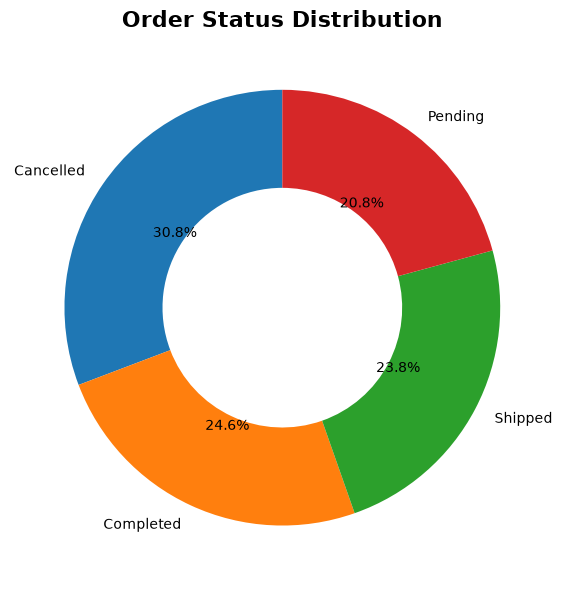

In [216]:
status = data['status'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    status,
    labels=status.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Order Status Distribution", fontsize=16, weight='bold')

plt.tight_layout()

plt.show()

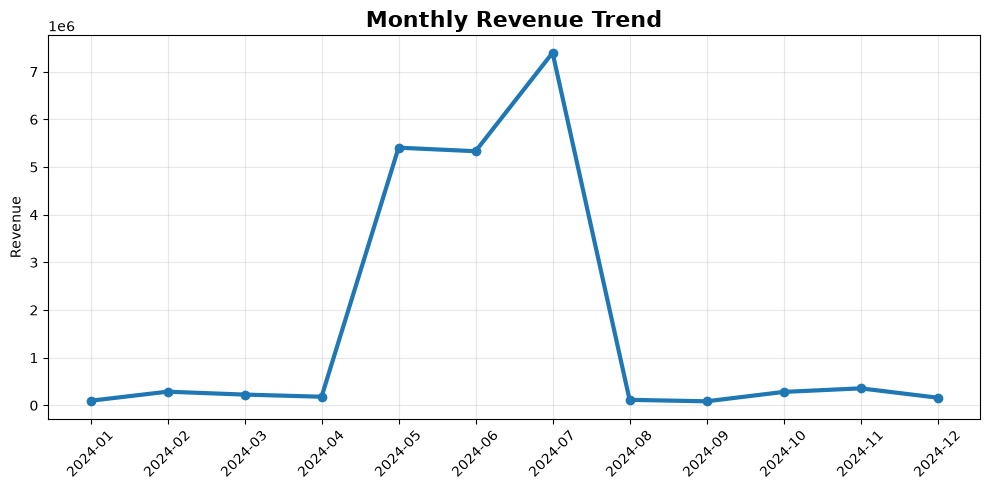

In [217]:
data['tanggal_order'] = pd.to_datetime(
    data['tanggal_order'],
    errors='coerce'
)

monthly = (
    data.groupby(data['tanggal_order'].dt.to_period('M'))
    ['total_harga']
    .sum()
)

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker='o',
    linewidth=3
)

plt.title("Monthly Revenue Trend", fontsize=16, weight='bold')

plt.ylabel("Revenue")

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

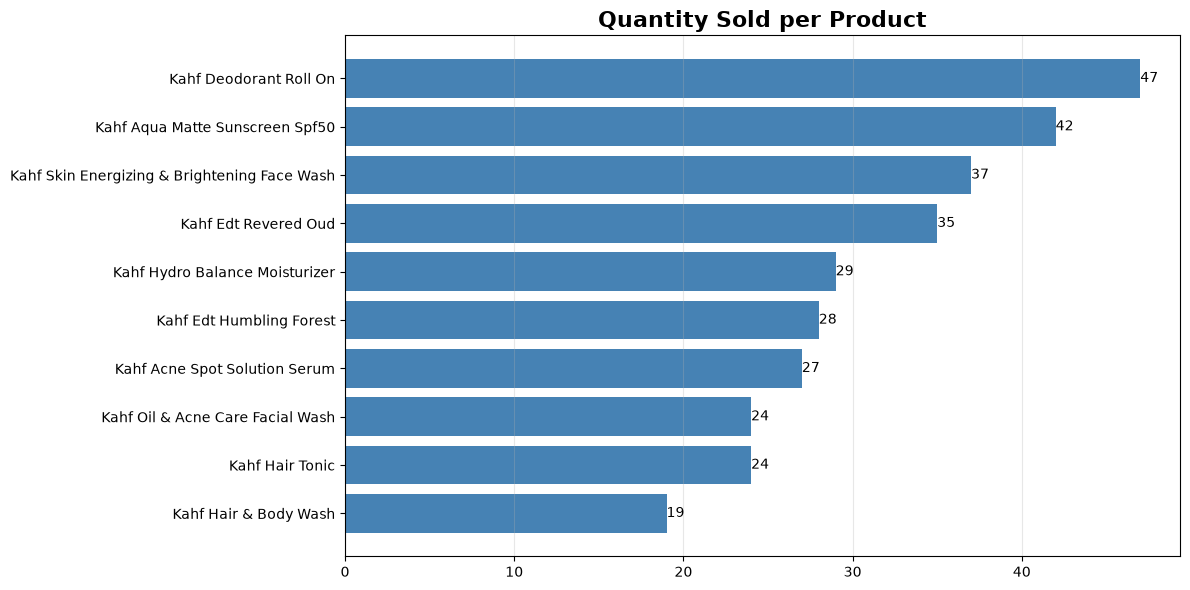

In [218]:
qty = (
    data.groupby('product_name')['quantity']
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,6))

bars = plt.barh(
    qty.index,
    qty.values,
    color='steelblue'
)

plt.title("Quantity Sold per Product", fontsize=16, weight='bold')

plt.grid(axis='x', alpha=0.3)

for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y()+bar.get_height()/2,
             int(bar.get_width()),
             va='center')

plt.tight_layout()

plt.show()

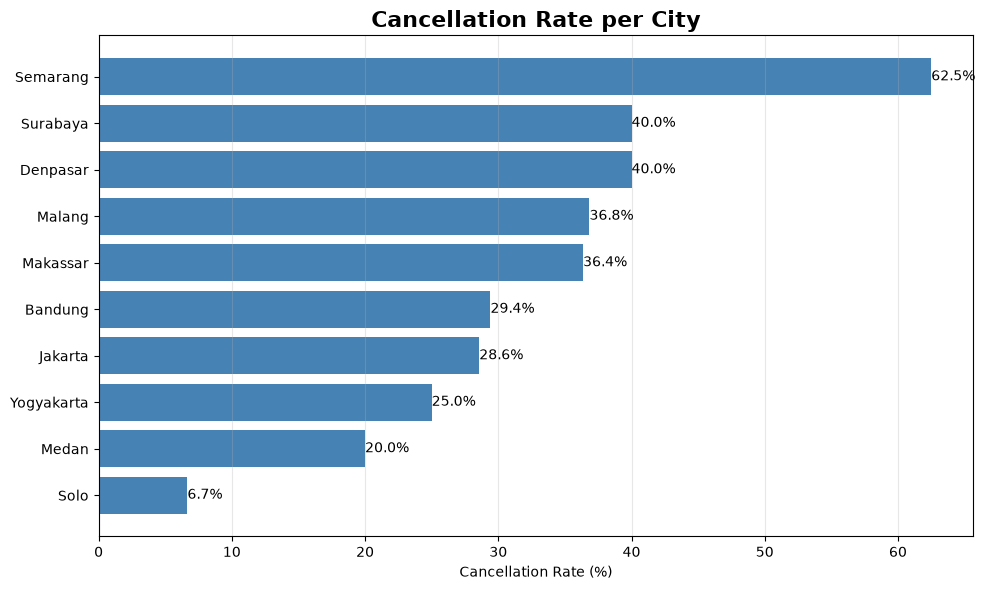

In [219]:
cancel = (
    data.assign(cancel=data['status'].eq('Cancelled'))
    .groupby('kota')['cancel']
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    cancel.index,
    cancel.values,
    color='steelblue'
)

plt.title("Cancellation Rate per City", fontsize=16, weight='bold')

plt.xlabel("Cancellation Rate (%)")

plt.grid(axis='x', alpha=0.3)

for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():.1f}%",
             va='center')

plt.tight_layout()

plt.show()

In [220]:
# Simpan ke CSV data setelah proses atau clean
data.to_csv(
    "../data/warehouse/orders_clean.csv",
    index=False,
    encoding="utf-8")
# Melihat kembali data yang disimpan
data = pd.read_csv("../data/warehouse/orders_clean.csv")
data.head()

,order_id,product_id,product_name,kategori,quantity,total_harga,tanggal_order,kota,channel,status,customer_email,harga_satuan
0,ORD-10122,P009,Kahf Edt Revered Oud,Fragrance,3,447000,2024-07-06,Denpasar,Website,Cancelled,customer3@email.com,149000
1,ORD-10107,P008,Kahf Hair Tonic,Hair Care,3,126000,2024-12-07,Solo,Marketplace,Pending,customer45@email.com,42000
2,ORD-10128,P001,Kahf Oil & Acne Care Facial Wash,Face Care,1,32000,2024-05-19,Jakarta,Website,Pending,customer9@email.com,32000
3,ORD-10001,P008,Kahf Hair Tonic,Hair Care,5,210000,2024-05-24,Bandung,Marketplace,Completed,customer13@email.com,42000
4,ORD-10053,P002,Kahf Skin Energizing & Brightening Face Wash,Face Care,1,34000,2024-07-08,Malang,Marketplace,Cancelled,customer22@email.com,34000
